going to get looking at some data

In [2]:
import pandas as pd
import numpy as np

big_data_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\2015-2025jSPXoptions.csv"

big_data = pd.read_csv(big_data_filepath)


In [3]:
# Inspect data structure
print("Dataset shape:", big_data.shape)
print("\nColumn names and types:")
print(big_data.info())
print("\nFirst few rows:")
print(big_data.head(5))
print("\nBasic statistics:")
print(big_data.describe())
print("\nData types:")
print(big_data.dtypes)
print("\nMissing values:")
print(big_data.isnull().sum())

Dataset shape: (42225530, 23)

Column names and types:
<class 'pandas.DataFrame'>
RangeIndex: 42225530 entries, 0 to 42225529
Data columns (total 23 columns):
 #   Column            Dtype  
---  ------            -----  
 0   secid             int64  
 1   date              str    
 2   symbol            str    
 3   exdate            str    
 4   cp_flag           str    
 5   strike_price      int64  
 6   best_bid          float64
 7   best_offer        float64
 8   volume            int64  
 9   open_interest     int64  
 10  impl_volatility   float64
 11  delta             float64
 12  gamma             float64
 13  vega              float64
 14  theta             float64
 15  optionid          int64  
 16  forward_price     float64
 17  expiry_indicator  str    
 18  index_flag        int64  
 19  issue_type        str    
 20  industry_group    float64
 21  issuer            str    
 22  exercise_style    str    
dtypes: float64(9), int64(6), str(8)
memory usage: 7.2 GB
None

Fi

In [4]:
columns_to_keep = ["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                    "optionid", "exercise_style", "delta", "vega", "gamma", "impl_volatility"]

filtered_data = big_data[columns_to_keep]
# Rename strike_price to K and divide by 1000
filtered_data = filtered_data.rename(columns={'strike_price': 'K'})
filtered_data['K'] = filtered_data['K'] / 1000

print(filtered_data.head(5))

#about equal number of calls and puts
#only european options

    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  02/01/2015  17/01/2015       C   100.0    1956.4      1959.6   
1  108105  02/01/2015  17/01/2015       C  1000.0    1056.7      1059.9   
2  108105  02/01/2015  17/01/2015       C  1025.0    1031.7      1034.9   
3  108105  02/01/2015  17/01/2015       C  1050.0    1006.7      1009.8   
4  108105  02/01/2015  17/01/2015       C  1075.0     981.7       984.8   

    optionid exercise_style     delta      vega     gamma  impl_volatility  
0  101234071              E       NaN       NaN       NaN              NaN  
1  101234072              E  0.999103  1.179546  0.000006         1.222229  
2  101234073              E  0.999083  1.204660  0.000006         1.181493  
3  101234074              E  0.999391  0.808892  0.000005         1.092237  
4  101234075              E  0.999382  0.820990  0.000005         1.054338  


In [5]:
# Convert date column to datetime format (dd/mm/yyyy)
filtered_data['date'] = pd.to_datetime(filtered_data['date'], format='%d/%m/%Y')
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'], format='%d/%m/%Y')

# Filter data to only include dates between 02/16/2017 and 01/07/2021
cutoff_date_start = pd.to_datetime('2017-10-16')
cutoff_date_end = pd.to_datetime('2021-07-01')
filtered_data = filtered_data[(filtered_data['date'] >= cutoff_date_start) & (filtered_data['date'] < cutoff_date_end)]

print(f"Dataset shape after date filter: {filtered_data.shape}")
print(f"\nDate range: {filtered_data['date'].min()} to {filtered_data['date'].max()}")
print(f"\nFirst few rows:")
print(filtered_data.head())

Dataset shape after date filter: (14062856, 13)

Date range: 2017-10-16 00:00:00 to 2021-06-30 00:00:00

First few rows:
          secid       date     exdate cp_flag       K  best_bid  best_offer  \
5693176  108105 2017-10-16 2017-10-20       C  1000.0    1554.8      1560.4   
5693177  108105 2017-10-16 2017-10-20       C  1100.0    1454.9      1460.5   
5693178  108105 2017-10-16 2017-10-20       C  1200.0    1354.9      1360.5   
5693179  108105 2017-10-16 2017-10-20       C  1225.0    1329.9      1335.5   
5693180  108105 2017-10-16 2017-10-20       C  1250.0    1304.9      1310.5   

          optionid exercise_style  delta  vega  gamma  impl_volatility  
5693176  116329689              E    NaN   NaN    NaN              NaN  
5693177  116329690              E    NaN   NaN    NaN              NaN  
5693178  116329691              E    NaN   NaN    NaN              NaN  
5693179  116329692              E    NaN   NaN    NaN              NaN  
5693180  116329693              E    Na

In [6]:
# Load SPX price data
spx_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\S&P 500 Historical Data 2015-2022.csv"  # Update filename if needed

spx_data = pd.read_csv(spx_filepath)

# Convert SPX date column to datetime format (mm/dd/yyyy)
spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')

# Convert both date columns to date only (removing time component) for proper merging
# First ensure filtered_data['date'] is datetime before converting
if not pd.api.types.is_datetime64_any_dtype(filtered_data['date']):
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
filtered_data['date'] = filtered_data['date'].dt.date
filtered_data['exdate'] = filtered_data['exdate'].dt.date
spx_data['Date'] = spx_data['Date'].dt.date

print(spx_data.head())

# Merge filtered_data with spx_data on date columns
filtered_data = filtered_data.merge(spx_data[['Date', 'Price']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Rename 'Price' to 'S' and drop the duplicate 'Date' column
filtered_data = filtered_data.rename(columns={'Price': 'S'})
filtered_data = filtered_data.drop(columns=['Date'])



# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         Date    Price      Open      High       Low  Vol. Change %
0  2025-10-03  6715.79  6,722.14  6,750.87  6,705.67   NaN    0.01%
1  2025-10-02  6715.35  6,731.31  6,731.94  6,693.23   NaN    0.06%
2  2025-10-01  6711.20  6,664.92  6,718.48  6,656.20   NaN    0.34%
3  2025-09-30  6688.46  6,656.19  6,691.25  6,641.00   NaN    0.41%
4  2025-09-29  6661.21  6,661.58  6,677.31  6,644.49   NaN    0.26%
Merge complete!
Filtered data shape: (14062856, 14)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2017-10-16  2017-10-20       C  1000.0    1554.8      1560.4   
1  108105  2017-10-16  2017-10-20       C  1100.0    1454.9      1460.5   
2  108105  2017-10-16  2017-10-20       C  1200.0    1354.9      1360.5   
3  108105  2017-10-16  2017-10-20       C  1225.0    1329.9      1335.5   
4  108105  2017-10-16  2017-10-20       C  1250.0    1304.9      1310.5   

    optionid exercise_style  delta  vega  gamma  impl_volatility       S

In [7]:
vix_filepath = r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Data\Full_VIX_History.csv"  # Update filename if needed

vix_data = pd.read_csv(vix_filepath)

# Convert VIX date column to datetime format (mm/dd/yyyy)
vix_data['DATE'] = pd.to_datetime(vix_data['DATE'], format='%m/%d/%Y')

# Convert DATE to date only (removing time component) to match filtered_data['date']
vix_data['DATE'] = vix_data['DATE'].dt.date


print(vix_data.head())

# Merge filtered_data with vix_data on date columns
filtered_data = filtered_data.merge(vix_data[['DATE', 'CLOSE']], 
                                    left_on='date', 
                                    right_on='DATE', 
                                    how='left')

# Rename 'CLOSE' to 'sigma' and drop the duplicate 'DATE' column
filtered_data = filtered_data.rename(columns={'CLOSE': 'sigma'})
filtered_data = filtered_data.drop(columns=['DATE'])

#turn sigma into percentage
filtered_data['sigma'] = filtered_data['sigma'] / 100

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         DATE   OPEN   HIGH    LOW  CLOSE
0  1990-01-02  17.24  17.24  17.24  17.24
1  1990-01-03  18.19  18.19  18.19  18.19
2  1990-01-04  19.22  19.22  19.22  19.22
3  1990-01-05  20.11  20.11  20.11  20.11
4  1990-01-08  20.26  20.26  20.26  20.26
Merge complete!
Filtered data shape: (14062856, 15)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2017-10-16  2017-10-20       C  1000.0    1554.8      1560.4   
1  108105  2017-10-16  2017-10-20       C  1100.0    1454.9      1460.5   
2  108105  2017-10-16  2017-10-20       C  1200.0    1354.9      1360.5   
3  108105  2017-10-16  2017-10-20       C  1225.0    1329.9      1335.5   
4  108105  2017-10-16  2017-10-20       C  1250.0    1304.9      1310.5   

    optionid exercise_style  delta  vega  gamma  impl_volatility       S  \
0  116329689              E    NaN   NaN    NaN              NaN  2557.6   
1  116329690              E    NaN   NaN    NaN              NaN  2557.6   


In [8]:
#want to add interest rates now!!!
interestrate_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yield-curve-rates-2015-2025.csv"  # Update filename if needed

ir_data = pd.read_csv(interestrate_filepath)

def parse_mixed_date(date_str):
    try:
        # Try mm/dd/yyyy format first
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except:
        try:
            # Fall back to mm/dd/yy format
            return pd.to_datetime(date_str, format='%m/%d/%y')
        except:
            print(f"Unrecognized date format: {date_str}")

ir_data['Date'] = ir_data['Date'].apply(parse_mixed_date).dt.date

# Rename columns
ir_data = ir_data.rename(columns={
    '1 Mo': 'r 1 Mo',
    '3 Mo': 'r 3 Mo',
    '6 Mo': 'r 6 Mo'
})

# Merge interest rate data with filtered_data
filtered_data = filtered_data.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Drop the duplicate Date column
filtered_data = filtered_data.drop(columns=['Date'])

rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    filtered_data[c] = (
        filtered_data[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    filtered_data[c] = pd.to_numeric(filtered_data[c], errors='coerce')

# now divide by 100 (if the values are in percent units like 5.25)
filtered_data[rate_cols] = filtered_data[rate_cols] / 100


print("Interest rate merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"Columns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())



Interest rate merge complete!
Filtered data shape: (14062856, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2017-10-16  2017-10-20       C  1000.0    1554.8      1560.4   
1  108105  2017-10-16  2017-10-20       C  1100.0    1454.9      1460.5   
2  108105  2017-10-16  2017-10-20       C  1200.0    1354.9      1360.5   
3  108105  2017-10-16  2017-10-20       C  1225.0    1329.9      1335.5   
4  108105  2017-10-16  2017-10-20       C  1250.0    1304.9      1310.5   

    optionid exercise_style  delta  vega  gamma  impl_volatility       S  \
0  116329689              E    NaN   NaN    NaN              NaN  2557.6   
1  116329690              E    NaN   NaN    NaN              NaN  2557.6   
2  116329691              E    NaN   NaN

In [9]:
# Convert S and K to numeric types
filtered_data['S'] = pd.to_numeric(filtered_data['S'], errors='coerce')
filtered_data['K'] = pd.to_numeric(filtered_data['K'], errors='coerce')

# Convert date columns back to datetime for arithmetic operations
filtered_data['date'] = pd.to_datetime(filtered_data['date'])
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'])

# Calculate new columns
# mid: midpoint of bid-ask spread
filtered_data['mid'] = (filtered_data['best_bid'] + filtered_data['best_offer']) / 2

# T: time to expiration in years
filtered_data['T'] = (filtered_data['exdate'] - filtered_data['date']).dt.days / 365.0

# Log-moneyness: log(S/K)
filtered_data['log_moneyness'] = np.log(filtered_data['S'] / filtered_data['K'])

# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

# Debug: Check cp_flag values before mapping
print("cp_flag values before mapping:")
print(filtered_data['cp_flag'].unique())
print(f"cp_flag data type: {filtered_data['cp_flag'].dtype}")
print(f"cp_flag null count: {filtered_data['cp_flag'].isnull().sum()}")

filtered_data["cp_flag"] = filtered_data["cp_flag"].map({"C": 1, "P": 0})

print("\nNew columns created!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nColumns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())
print(filtered_data.tail())

# Print unique cp_flag values
print("\nUnique cp_flag values in training data:", filtered_data['cp_flag'].unique())
print("Unique cp_flag values in test data:", filtered_data['cp_flag'].unique())





cp_flag values before mapping:
<StringArray>
['C', 'P']
Length: 2, dtype: str
cp_flag data type: str
cp_flag null count: 0

New columns created!
Filtered data shape: (14062856, 21)

Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo', 'mid', 'T', 'log_moneyness']

First few rows:
    secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0  108105 2017-10-16 2017-10-20        1  1000.0    1554.8      1560.4   
1  108105 2017-10-16 2017-10-20        1  1100.0    1454.9      1460.5   
2  108105 2017-10-16 2017-10-20        1  1200.0    1354.9      1360.5   
3  108105 2017-10-16 2017-10-20        1  1225.0    1329.9      1335.5   
4  108105 2017-10-16 2017-10-20        1  1250.0    1304.9      1310.5   

    optionid exercise_style  delta  ...  gamma  impl_volatility       S  \
0  116329689              E    NaN  ...    NaN        

In [10]:
#putting in Black scholes price for feature
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price_row(S, K, T, r, sigma, cp_flag):
    # Basic guards
    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if cp_flag == 1:  # Call
        return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
    else:            # Put
        return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
filtered_data["bs_price"] = filtered_data.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(filtered_data[["S","K","T",r_col,"sigma","cp_flag","mid","bs_price", "delta", "vega", "gamma", "impl_volatility"]].head())

Added bs_price column.
        S       K         T  r 3 Mo   sigma  cp_flag     mid     bs_price  \
0  2557.6  1000.0  0.010959   0.011  0.0991        1  1557.6  1557.720541   
1  2557.6  1100.0  0.010959   0.011  0.0991        1  1457.7  1457.732595   
2  2557.6  1200.0  0.010959   0.011  0.0991        1  1357.7  1357.744649   
3  2557.6  1225.0  0.010959   0.011  0.0991        1  1332.7  1332.747662   
4  2557.6  1250.0  0.010959   0.011  0.0991        1  1307.7  1307.750676   

   delta  vega  gamma  impl_volatility  
0    NaN   NaN    NaN              NaN  
1    NaN   NaN    NaN              NaN  
2    NaN   NaN    NaN              NaN  
3    NaN   NaN    NaN              NaN  
4    NaN   NaN    NaN              NaN  


In [11]:
# # Check if optionid 134606380 exists in the dataset
# target_id = 134606380
# if target_id in filtered_data['optionid'].values:
#     print(f"Found optionid {target_id}!")
#     print("\nRow(s) with this optionid:")
#     print(filtered_data[filtered_data['optionid'] == target_id])
# else:
#     print(f"optionid {target_id} NOT found in the dataset")

should probs build test data set before moving on


In [20]:
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\30day134606830.csv"
option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\moneyness\\OTMoption.csv"
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yearlongatmoption.csv"

option = pd.read_csv(option_filepath)

# Convert dates to datetime and then to date for merging
option['date'] = pd.to_datetime(option['date'], format='%d/%m/%Y').dt.date
option['exdate'] = pd.to_datetime(option['exdate'], format='%d/%m/%Y')

# Rename strike_price to K and divide by 1000
option = option.rename(columns={'strike_price': 'K'})
option['K'] = option['K'] / 1000

option["cp_flag"] = "C"

# Merge with SPX data (Date column is already in date format from earlier processing)
option = option.merge(spx_data[['Date', 'Price']], 
                     left_on='date', right_on='Date', how='left')
option = option.rename(columns={'Price': 'S'}).drop(columns=['Date'])

# Merge with VIX data (DATE column is already in date format from earlier processing)
option = option.merge(vix_data[['DATE', 'CLOSE']], 
                     left_on='date', right_on='DATE', how='left')
option = option.rename(columns={'CLOSE': 'sigma'}).drop(columns=['DATE'])
#turn sigma into percentage
option['sigma'] = option['sigma'] / 100

# Merge with interest rate data (Date column is already in date format from earlier processing)
option = option.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                     left_on='date', right_on='Date', how='left')
option = option.drop(columns=['Date'])
rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    option[c] = (
        option[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    option[c] = pd.to_numeric(option[c], errors='coerce')
# now divide by 100 (if the values are in percent units like 5.25)
option[rate_cols] = option[rate_cols] / 100


# Convert to numeric and calculate derived columns
option['S'] = pd.to_numeric(option['S'], errors='coerce')
option['K'] = pd.to_numeric(option['K'], errors='coerce')
option['date'] = pd.to_datetime(option['date'])

option['mid'] = (option['best_bid'] + option['best_offer']) / 2
option['T'] = (option['exdate'] - option['date']).dt.days / 365.0
option['log_moneyness'] = np.log(option['S'] / option['K'])




columns = ["date","S", "K", "T", "log_moneyness", "sigma", "cp_flag", "mid", "r 1 Mo", "r 3 Mo", "r 6 Mo", "bs_price",  "delta", "vega", "gamma", "impl_volatility"]


option["cp_flag"] = option["cp_flag"].map({"C": 1, "P": 0})
#going to put in black scholes price for feature
# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
option["bs_price"] = option.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(option.head())


option_clean = option[columns]

print(option_clean.head())
print(option_clean.describe())



Added bs_price column.
    optionid   secid       date     exdate  cp_flag       K  best_bid  \
0  139881236  108105 2021-07-01 2021-09-17        1  4580.0      11.0   
1  139881236  108105 2021-07-02 2021-09-17        1  4580.0      14.6   
2  139881236  108105 2021-07-06 2021-09-17        1  4580.0      13.8   
3  139881236  108105 2021-07-07 2021-09-17        1  4580.0      16.3   
4  139881236  108105 2021-07-08 2021-09-17        1  4580.0      12.3   

   best_offer  volume  impl_volatility  ...  exercise_style       S   sigma  \
0        11.4      31         0.106314  ...               E  4319.9  0.1548   
1        15.0       0         0.105521  ...               E  4352.3  0.1507   
2        14.1       0         0.108734  ...               E  4343.5  0.1644   
3        16.6       2         0.110950  ...               E  4358.1  0.1620   
4        12.7       0         0.114448  ...               E  4320.8  0.1900   

   r 1 Mo  r 3 Mo  r 6 Mo    mid         T  log_moneyness   bs_

Going to start training the model on data, probs start small then increase it


In [25]:
import numpy as np
import pandas as pd


from sklearn.model_selection import GroupKFold
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split



TRAIN_FULL = filtered_data.copy(deep=True)
TEST_FULL  = option_clean.copy(deep=True)



In [26]:
import numpy as np
import pandas as pd
FEATURES = ["T", "log_moneyness", "sigma", "r 3 Mo", "bs_price",] #"delta", "vega", "gamma", "impl_volatility"]  # "delta", "vega", "gamma", "impl_volatility"
           

# ----------------------------
# 1) Rebuild base data
# ----------------------------
train_df = TRAIN_FULL.copy()
test_df  = TEST_FULL.copy()

train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"]  = pd.to_datetime(test_df["date"])

print("TRAIN_FULL shape:", train_df.shape)
print("TEST_FULL shape: ", test_df.shape)

# ----------------------------
# 2) Clean target + basic guards
# ----------------------------
train_df = train_df[np.isfinite(train_df["mid"]) & (train_df["mid"] > 0) & (train_df["T"] > 0)].copy()

# ----------------------------
# 3) Filters (time window + moneyness + maturity + calls only)
# ----------------------------
MIN_T, MAX_T = 0.0000136986301, 1
MIN_M, MAX_M = -0.5, 0.5
cutoff_date_start = pd.to_datetime("2019-07-01")
cutoff_date_end   = pd.to_datetime("2021-06-30")

mask = (
    train_df["T"].between(MIN_T, MAX_T)
    & train_df["log_moneyness"].between(MIN_M, MAX_M)
    & (train_df["date"] >= cutoff_date_start)
    & (train_df["date"] <  cutoff_date_end)
)
train_df = train_df.loc[mask].copy()
train_df = train_df[train_df["cp_flag"] == 1].copy()

# ---- NEW: drop rows with NaN in any feature ----
n_before = len(train_df)
train_df = train_df.dropna(subset=FEATURES).copy()
n_after = len(train_df)
print(f"Dropped {n_before - n_after} rows with NaN in features "
      f"({100*(n_before - n_after)/n_before:.2f}%)")
# -------------------------------------------------

print(f"\nFiltered TRAIN date range: {train_df['date'].min()} to {train_df['date'].max()}")
print("Filtered TRAIN shape (calls only, no NaN):", train_df.shape)

# ----------------------------
# 4) Subsample (compute budget), then restore chronological order
# ----------------------------
SAMPLE_SIZE = min(1000000, len(train_df))
train_df = (train_df
            .sample(n=SAMPLE_SIZE, random_state=21)
            .sort_values("date")
            .reset_index(drop=True))
print("TRAIN shape after sampling + chronological sort:", train_df.shape)

# ----------------------------
# 5) Untouched test set (used ONLY for final evaluation)
# ----------------------------

test_df = test_df[np.isfinite(test_df["mid"]) & (test_df["mid"] > 0) & (test_df["T"] > 0)].copy()
test_df = test_df.dropna(subset=FEATURES).copy()  

X_test = test_df[FEATURES].copy()
y_test = test_df["mid"].copy()

print("\nUnique cp_flag in Train:", train_df["cp_flag"].unique())
print("Unique cp_flag in Test: ", test_df["cp_flag"].unique())

print("\nTraining features preview:")
print(train_df[FEATURES].head(10))

print("\nTest features preview:")
print(test_df[FEATURES].head(10))

TRAIN_FULL shape: (14062856, 22)
TEST_FULL shape:  (54, 16)
Dropped 26237 rows with NaN in features (0.74%)

Filtered TRAIN date range: 2019-07-01 00:00:00 to 2021-06-29 00:00:00
Filtered TRAIN shape (calls only, no NaN): (3501835, 22)
TRAIN shape after sampling + chronological sort: (1000000, 22)

Unique cp_flag in Train: [1]
Unique cp_flag in Test:  [1]

Training features preview:
          T  log_moneyness   sigma  r 3 Mo     bs_price
0  0.334247       0.162382  0.1406  0.0221   464.323086
1  0.126027       0.368801  0.1406  0.0221   920.001727
2  0.298630       0.264661  0.1406  0.0221   704.275231
3  0.164384       0.418812  0.1406  0.0221  1021.371257
4  0.969863      -0.052793  0.1406  0.0221   123.244005
5  0.164384      -0.000236  0.1406  0.0221    72.435428
6  0.221918      -0.047982  0.1406  0.0221    31.140450
7  0.413699       0.170350  0.1406  0.0221   489.217879
8  0.164384      -0.043147  0.1406  0.0221    24.906113
9  0.024658       0.498854  0.1406  0.0221  1165.28061

In [74]:
# =======================================================
# CELL 1: LGBM HYPERPARAMETER SEARCH WITH TIMESERIESSPLIT
# =======================================================

import time
import pickle
import numpy as np
import pandas as pd

import lightgbm as lgb
from lightgbm import LGBMRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# -------------------------------------------------------
# Build chronologically sorted CV pool from training set
# -------------------------------------------------------
cv_df = train_df.sort_values("date").reset_index(drop=True)

X_cv = cv_df[FEATURES].copy()
y_cv = cv_df["mid"].copy()

tscv = TimeSeriesSplit(n_splits=5)


# -------------------------------------------------------
# Hyperparameter grid
# -------------------------------------------------------
# n_estimators is deliberately large.
# early_stopping chooses the effective number of trees.
N_ESTIMATORS_CAP = 10000
EARLY_STOPPING_ROUNDS = 100

list_learning_rate     = [0.01, 0.03, 0.05, 0.07, 0.10, 0.20]
list_num_leaves        = [31, 63, 127, 255]
list_min_child_samples = [25, 50, 100]
list_subsample         = [0.8, 1.0]
list_colsample         = [0.8, 1.0]

list_of_hparams = [
    (lr, nl, mcs, ss, cs)
    for lr  in list_learning_rate
    for nl  in list_num_leaves
    for mcs in list_min_child_samples
    for ss  in list_subsample
    for cs  in list_colsample
]

print("Total combos:", len(list_of_hparams))
print("Total fits:", len(list_of_hparams) * tscv.get_n_splits())


best_val_rmse = np.inf
best_hparams = None
results = []

overall_start = time.time()


# -------------------------------------------------------
# Grid search loop
# -------------------------------------------------------
for i, (learning_rate, num_leaves, min_child_samples, subsample, colsample_bytree) in enumerate(list_of_hparams, 1):

    print(
        f"\nRun {i}/{len(list_of_hparams)} | "
        f"lr={learning_rate}, leaves={num_leaves}, "
        f"min_child={min_child_samples}, subsample={subsample}, "
        f"colsample={colsample_bytree}"
    )

    fold_train_rmses = []
    fold_val_rmses = []
    fold_best_iters = []

    run_start = time.time()

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_cv), 1):

        X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        lgbm = LGBMRegressor(
            objective="regression",
            boosting_type="gbdt",

            learning_rate=learning_rate,
            n_estimators=N_ESTIMATORS_CAP,
            num_leaves=num_leaves,
            min_child_samples=min_child_samples,

            subsample=subsample,
            subsample_freq=1 if subsample < 1.0 else 0,
            colsample_bytree=colsample_bytree,

            reg_alpha=0.0,
            reg_lambda=1.0,

            random_state=42,
            n_jobs=-1,
            verbose=-1,
            force_col_wise=True,
        )

        lgbm.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                lgb.log_evaluation(0)
            ],
        )

        best_iter = lgbm.best_iteration_
        if best_iter is None or best_iter <= 0:
            best_iter = N_ESTIMATORS_CAP

        pred_train = lgbm.predict(X_tr, num_iteration=best_iter)
        pred_val   = lgbm.predict(X_va, num_iteration=best_iter)

        fold_train_rmse = rmse(y_tr, pred_train)
        fold_val_rmse   = rmse(y_va, pred_val)

        fold_train_rmses.append(fold_train_rmse)
        fold_val_rmses.append(fold_val_rmse)
        fold_best_iters.append(best_iter)

        print(
            f"   fold {fold_idx}/5 | "
            f"n_train={len(tr_idx):>7} | n_val={len(va_idx):>7} | "
            f"best_iter={best_iter:>5} | "
            f"train RMSE={fold_train_rmse:.4f} | val RMSE={fold_val_rmse:.4f}"
        )

    mean_train_rmse = float(np.mean(fold_train_rmses))
    mean_val_rmse   = float(np.mean(fold_val_rmses))
    overfit_gap     = mean_val_rmse - mean_train_rmse

    mean_best_iter   = int(np.round(np.mean(fold_best_iters)))
    median_best_iter = int(np.round(np.median(fold_best_iters)))

    elapsed_run = time.time() - run_start

    marker = "  <-- new best" if mean_val_rmse < best_val_rmse else ""

    print(
        f"   --> mean train RMSE={mean_train_rmse:.4f} | "
        f"mean val RMSE={mean_val_rmse:.4f} | "
        f"gap={overfit_gap:+.4f} | "
        f"mean_iter={mean_best_iter} | "
        f"time={elapsed_run/60:.2f} min"
        f"{marker}"
    )

    if mean_val_rmse < best_val_rmse:
        best_val_rmse = mean_val_rmse
        best_hparams = (
            learning_rate,
            num_leaves,
            min_child_samples,
            subsample,
            colsample_bytree,
            mean_best_iter,
            median_best_iter,
        )

    results.append({
        "method": "LightGBM",
        "learning_rate": learning_rate,
        "num_leaves": num_leaves,
        "min_child_samples": min_child_samples,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "mean_best_iteration": mean_best_iter,
        "median_best_iteration": median_best_iter,
        "rmse_train": mean_train_rmse,
        "rmse_val": mean_val_rmse,
        "overfit_gap": overfit_gap,
        "overfit_ratio": overfit_gap / mean_val_rmse if mean_val_rmse > 0 else np.nan,
    })


# -------------------------------------------------------
# Results table
# -------------------------------------------------------
results_df = pd.DataFrame(results)

print("\nTop 10 models by mean validation RMSE:")
print(results_df.sort_values("rmse_val").head(10).to_string(index=False))

print("\nTop 10 models by overfit-controlled validation RMSE:")

controlled_df = results_df[results_df["overfit_gap"] <= 0.30 * results_df["rmse_val"]].copy()

if len(controlled_df) == 0:
    print("No models passed the 30% overfit filter. Relaxing to 50%.")
    controlled_df = results_df[results_df["overfit_gap"] <= 0.50 * results_df["rmse_val"]].copy()

if len(controlled_df) == 0:
    print("No models passed the 50% overfit filter. Falling back to lowest validation RMSE.")
    controlled_df = results_df.copy()

print(controlled_df.sort_values("rmse_val").head(10).to_string(index=False))

print("\nBest raw hparams:")
print(best_hparams)
print(f"Best raw mean validation RMSE = {best_val_rmse:.6f}")

overall_elapsed = time.time() - overall_start
print(f"\nTotal search time: {overall_elapsed/60:.2f} min")

Total combos: 288
Total fits: 1440

Run 1/288 | lr=0.01, leaves=31, min_child=25, subsample=0.8, colsample=0.8
   fold 1/5 | n_train=  83335 | n_val=  83333 | best_iter= 1251 | train RMSE=2.1711 | val RMSE=30.5771
   fold 2/5 | n_train= 166668 | n_val=  83333 | best_iter= 1878 | train RMSE=2.7937 | val RMSE=16.8675
   fold 3/5 | n_train= 250001 | n_val=  83333 | best_iter= 1273 | train RMSE=3.4254 | val RMSE=14.8191
   fold 4/5 | n_train= 333334 | n_val=  83333 | best_iter= 2726 | train RMSE=3.2550 | val RMSE=21.5515
   fold 5/5 | n_train= 416667 | n_val=  83333 | best_iter= 1899 | train RMSE=3.9385 | val RMSE=15.1766
   --> mean train RMSE=3.1167 | mean val RMSE=19.7983 | gap=+16.6816 | mean_iter=1805 | time=1.17 min  <-- new best

Run 2/288 | lr=0.01, leaves=31, min_child=25, subsample=0.8, colsample=1.0
   fold 1/5 | n_train=  83335 | n_val=  83333 | best_iter= 1704 | train RMSE=2.0558 | val RMSE=36.2768
   fold 2/5 | n_train= 166668 | n_val=  83333 | best_iter= 1036 | train RMSE=3.

In [27]:
# =======================================================
# CELL 2: FINAL LGBM MODEL WITH MANUAL HYPERPARAMETERS
# =======================================================

import time
import pickle
import numpy as np
import pandas as pd

import lightgbm as lgb
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error


# -------------------------------------------------------
# MANUALLY INPUT FINAL HYPERPARAMETERS HERE
# Replace these with your best CV results from Cell 1
# -------------------------------------------------------

FINAL_LEARNING_RATE     = 0.07      # <- edit
FINAL_N_ESTIMATORS      = 3000  # <- edit
FINAL_NUM_LEAVES        = 255       # <- edit
FINAL_MIN_CHILD_SAMPLES = 50       # <- edit
FINAL_SUBSAMPLE         = 0.8       # <- edit
FINAL_COLSAMPLE_BYTREE  = 1       # <- edit

FINAL_REG_ALPHA         = 0.0       # <- edit if tuned
FINAL_REG_LAMBDA        = 1.0       # <- edit if tuned


print("Final LGBM hyperparameters:")
print(f"  learning_rate     = {FINAL_LEARNING_RATE}")
print(f"  n_estimators      = {FINAL_N_ESTIMATORS}")
print(f"  num_leaves        = {FINAL_NUM_LEAVES}")
print(f"  min_child_samples = {FINAL_MIN_CHILD_SAMPLES}")
print(f"  subsample         = {FINAL_SUBSAMPLE}")
print(f"  colsample_bytree  = {FINAL_COLSAMPLE_BYTREE}")
print(f"  reg_alpha         = {FINAL_REG_ALPHA}")
print(f"  reg_lambda        = {FINAL_REG_LAMBDA}")


# -------------------------------------------------------
# Full training data
# -------------------------------------------------------

full_train_df = train_df.sort_values("date").reset_index(drop=True)

X_full_train = full_train_df[FEATURES].copy()
y_full_train = full_train_df["mid"].copy()


# -------------------------------------------------------
# Train final model on full training set
# -------------------------------------------------------

lgbm_final = LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",

    learning_rate=FINAL_LEARNING_RATE,
    n_estimators=FINAL_N_ESTIMATORS,
    num_leaves=FINAL_NUM_LEAVES,
    min_child_samples=FINAL_MIN_CHILD_SAMPLES,

    subsample=FINAL_SUBSAMPLE,
    subsample_freq=1 if FINAL_SUBSAMPLE < 1.0 else 0,
    colsample_bytree=FINAL_COLSAMPLE_BYTREE,

    reg_alpha=FINAL_REG_ALPHA,
    reg_lambda=FINAL_REG_LAMBDA,

    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True,
)

print("\nTraining final LGBM model on full training set...")

start = time.time()
lgbm_final.fit(X_full_train, y_full_train)
elapsed = time.time() - start

print(f"Training completed in {elapsed/60:.2f} min ({elapsed:.1f} s)")


# -------------------------------------------------------
# Evaluate final model
# -------------------------------------------------------

pred_train_final = lgbm_final.predict(X_full_train)
pred_test_final  = lgbm_final.predict(X_test)


def report(name, y_true, y_pred):
    rmse_d = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_d  = mean_absolute_error(y_true, y_pred)
    bias_d = float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))

    print(f"\n=== {name} ===")
    print(f"  RMSE: {rmse_d:.6f}")
    print(f"  MAE:  {mae_d:.6f}")
    print(f"  Bias: {bias_d:.6f}")

    return rmse_d, mae_d, bias_d


rmse_tr, mae_tr, bias_tr = report("TRAIN (full)", y_full_train, pred_train_final)
rmse_te, mae_te, bias_te = report("TEST", y_test, pred_test_final)

print(f"\nGeneralisation gap (Test - Train RMSE): {rmse_te - rmse_tr:+.6f}")


# -------------------------------------------------------
# Optional: store predictions for downstream plotting
# -------------------------------------------------------

# test_df["pred_lgbm"] = pred_test_final


# -------------------------------------------------------
# Optional: save final model
# -------------------------------------------------------

# with open("lgbm_final.pkl", "wb") as f:
#     pickle.dump(lgbm_final, f)

# print("\nModel saved to lgbm_final.pkl")

Final LGBM hyperparameters:
  learning_rate     = 0.07
  n_estimators      = 3000
  num_leaves        = 255
  min_child_samples = 50
  subsample         = 0.8
  colsample_bytree  = 1
  reg_alpha         = 0.0
  reg_lambda        = 1.0

Training final LGBM model on full training set...
Training completed in 0.93 min (55.9 s)

=== TRAIN (full) ===
  RMSE: 1.825958
  MAE:  1.261171
  Bias: 0.000008

=== TEST ===
  RMSE: 4.025077
  MAE:  3.105724
  Bias: 2.806456

Generalisation gap (Test - Train RMSE): +2.199118


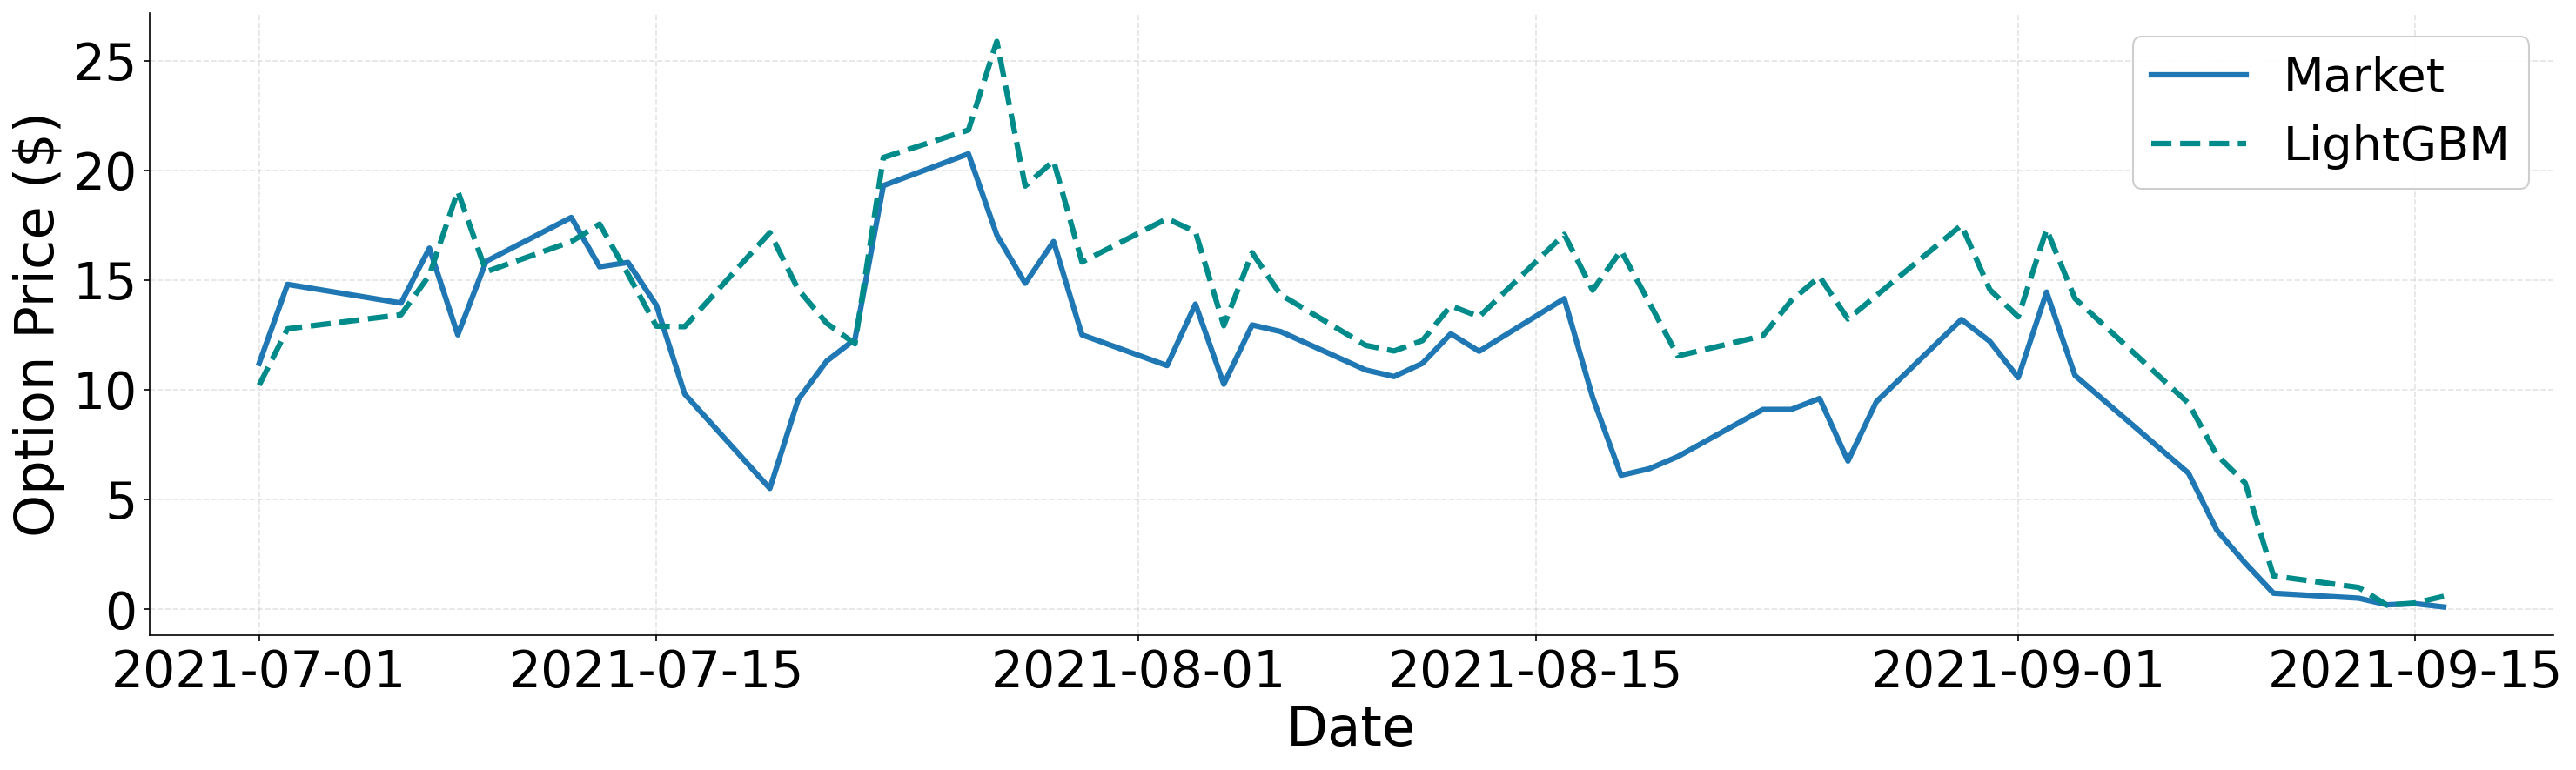

Saved PNG to: C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\moneyness\OTM option\market_vs_lightgbm_OTMoption.png


In [29]:
# ------------------------------------------------------------------
# Market vs ML model plot (ATM, short-dated test option)
# Copy this cell into each ML notebook; change the FOUR lines below.
# ------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- change these four for each model ----
MODEL_NAME_PRETTY = "LightGBM"
MODEL_COLOUR      = "#008B8B"          # teal
PRED              = pred_test_final    # whatever the test predictions are called
FILE_TAG          = "lightgbm"

# Reference palette for the other four notebooks:
#   XGBoost  -> "#E91E63"  magenta     tag: "xgboost"
#   Random Forest -> "#8B4513"  brown       tag: "lightgbm"
#   FFNN     -> "#B8860B"  goldenrod   tag: "ffnn"
#   LSTM     -> "#000000"  black       tag: "lstm"

save_dir = Path(r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\moneyness\OTM option")
save_dir.mkdir(parents=True, exist_ok=True)

# Align predictions with test_df order (safe if test_df was not re-sorted)
plot_df = test_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["pred"] = pd.Series(PRED).values
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# Figure: wider aspect (20:6) so five fit on one A4 page at 0.95\textwidth
fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

ax.plot(plot_df["date"], plot_df["mid"],
        linewidth=3, label="Market")
ax.plot(plot_df["date"], plot_df["pred"],
        linewidth=3, linestyle="--",
        color=MODEL_COLOUR, label=MODEL_NAME_PRETTY)

ax.set_xlabel("Date", fontsize=30)
ax.set_ylabel("Option Price ($)", fontsize=30)
ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=28)

leg = ax.legend(frameon=True, fontsize=26, loc="best")
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

png_path = save_dir / f"market_vs_{FILE_TAG}_OTMoption.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PNG to: {png_path}")
